# CS111 Project Template — Solving the 1D Heat Equation with the FFT

We solve the periodic heat equation

$$u_t = \kappa u_{xx}, \qquad x \in [0, 2\pi], \qquad u(x+2\pi,t)=u(x,t).$$

This notebook shows how the **Fourier basis** turns the PDE into many simple scalar equations, and how the **FFT** makes that computation fast.


## From finite differences to Fourier methods

In finite differences, we approximate derivatives locally on a grid.

For Fourier methods, we represent the solution as a sum of global sinusoidal modes:

$$u(x,t) = \sum_k \hat u_k(t)e^{ikx}.$$

This is useful because Fourier modes are eigenfunctions of differentiation:

$$\frac{d^2}{dx^2}e^{ikx} = -k^2 e^{ikx}.$$

So the second derivative becomes multiplication by $-k^2$ in Fourier space.

That means the PDE decouples into many independent scalar ODEs.


## Big picture of the algorithm

We will:

1. define a periodic initial condition
2. compute its FFT
3. build the wave number array
4. evolve each Fourier mode exactly in time
5. inverse FFT back to physical space
6. visualize the solution and the decay of high frequencies

This is a spectral method viewpoint: choose a basis that diagonalizes the operator.


## Step 0 — Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Step 1 — The heat equation in Fourier space

Start with

$$u_t = \kappa u_{xx}.$$

Write

$$u(x,t)=\sum_k \hat u_k(t)e^{ikx}.$$

Since

$$u_{xx} \longrightarrow -k^2 \hat u_k,$$

each Fourier coefficient satisfies

$$\frac{d\hat u_k}{dt} = -\kappa k^2 \hat u_k.$$

This is just a scalar ODE, so the exact solution is

$$\hat u_k(t) = e^{-\kappa k^2 t}\hat u_k(0).$$

This is the formula we will implement.


## Step 2 — Set up the spatial grid

We use a periodic grid on $[0,2\pi)$ with `n` points.

For FFT-based methods, periodic boundary conditions are the natural setting.


In [2]:
L = 2.0 * np.pi
n = 256
x = np.linspace(0.0, L, n, endpoint=False)
dx = x[1] - x[0]

kappa = 0.15

print('Grid points:', n)
print('dx:', dx)


Grid points: 256
dx: 0.02454369260617026


## Step 3 — Define the initial condition

Choose a periodic initial condition with several frequencies present.

This makes it easier to see that high-frequency oscillations decay faster than low-frequency ones.


In [3]:
def initial_condition(x):
    return (
        1.2 * np.sin(x)
        + 0.7 * np.sin(3 * x)
        + 0.3 * np.cos(8 * x)
        + 0.15 * np.sin(20 * x)
    )


u0 = initial_condition(x)


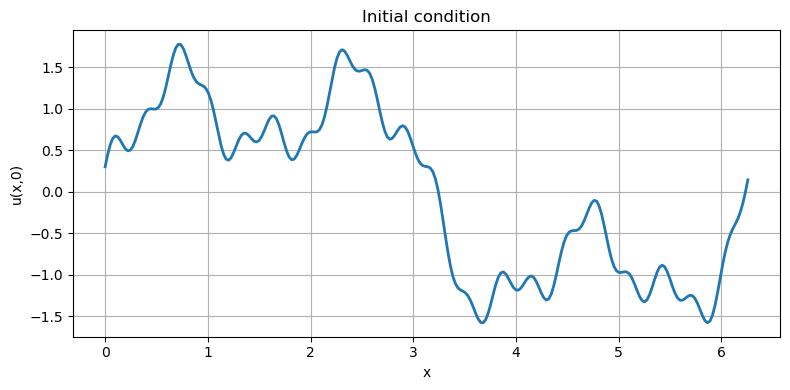

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(x, u0, linewidth=2)
plt.title('Initial condition')
plt.xlabel('x')
plt.ylabel('u(x,0)')
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 4 — Compute the FFT of the initial condition

The FFT returns the Fourier coefficients of the sampled function.

We use `numpy.fft.fft` as a computational tool. The scientific computing idea here is not implementing the FFT algorithm itself, but using the Fourier basis to solve the PDE efficiently.


In [5]:
u0_hat = np.fft.fft(u0)
print('Shape of Fourier coefficient array:', u0_hat.shape)


Shape of Fourier coefficient array: (256,)


## Step 5 — Build the wave number array

For the Fourier-space formula

$$\hat u_k(t) = e^{-\kappa k^2 t}\hat u_k(0),$$

we need the wave numbers $k$ associated with the FFT output ordering.

`numpy.fft.fftfreq` gives the frequency ordering compatible with `fft`.


In [6]:
k = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
print('First few wave numbers:')
print(k[:10])


First few wave numbers:
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


## Step 6 — Evolve the solution in Fourier space

Given time `t`, the exact Fourier-space solution is

$$\hat u_k(t) = e^{-\kappa k^2 t}\hat u_k(0).$$

Then we apply the inverse FFT to recover the physical-space solution.


In [7]:
def heat_solution_fft(u0, k, kappa, t):
    """Return the solution u(x,t) by evolving Fourier modes exactly."""
    u0_hat = np.fft.fft(u0)
    decay = np.exp(-kappa * (k**2) * t)
    u_hat_t = decay * u0_hat
    u_t = np.fft.ifft(u_hat_t)
    return np.real(u_t)


## Step 7 — Plot the solution at several times

This should show the smoothing effect of diffusion.

High-frequency oscillations disappear first.


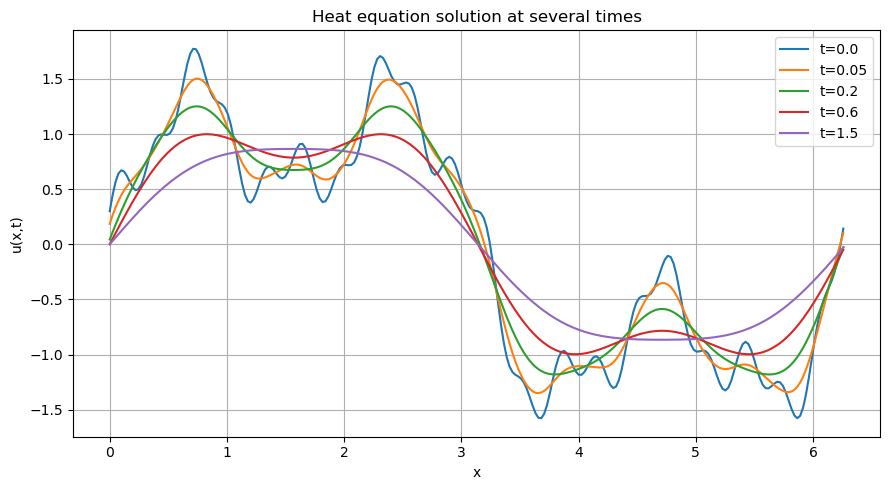

In [8]:
times = [0.0, 0.05, 0.2, 0.6, 1.5]

plt.figure(figsize=(9, 5))
for t in times:
    ut = heat_solution_fft(u0, k, kappa, t)
    plt.plot(x, ut, label=f't={t}')

plt.title('Heat equation solution at several times')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Step 8 — Why does diffusion smooth?

Each Fourier mode gets multiplied by

$$e^{-\kappa k^2 t}.$$

So:

- low-frequency modes ($|k|$ small) decay slowly
- high-frequency modes ($|k|$ large) decay very fast

That is why sharp oscillations disappear first.


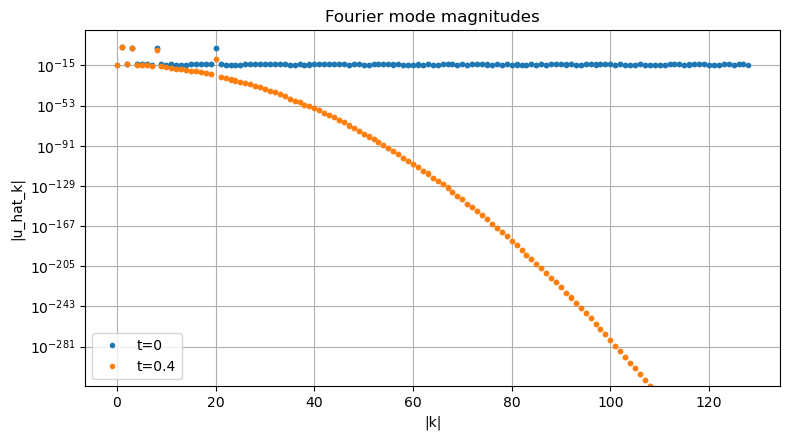

In [9]:
mode_strength_0 = np.abs(u0_hat)

t1 = 0.4
u_hat_t1 = np.exp(-kappa * (k**2) * t1) * u0_hat
mode_strength_t1 = np.abs(u_hat_t1)

order = np.argsort(np.abs(k))

plt.figure(figsize=(8, 4.5))
plt.semilogy(np.abs(k)[order], mode_strength_0[order], 'o', markersize=3, label='t=0')
plt.semilogy(np.abs(k)[order], mode_strength_t1[order], 'o', markersize=3, label=f't={t1}')
plt.title('Fourier mode magnitudes')
plt.xlabel('|k|')
plt.ylabel('|u_hat_k|')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Step 9 — Inspect the decay factor directly

We can also plot

$$e^{-\kappa k^2 t}$$

to see directly how strongly each mode is damped.


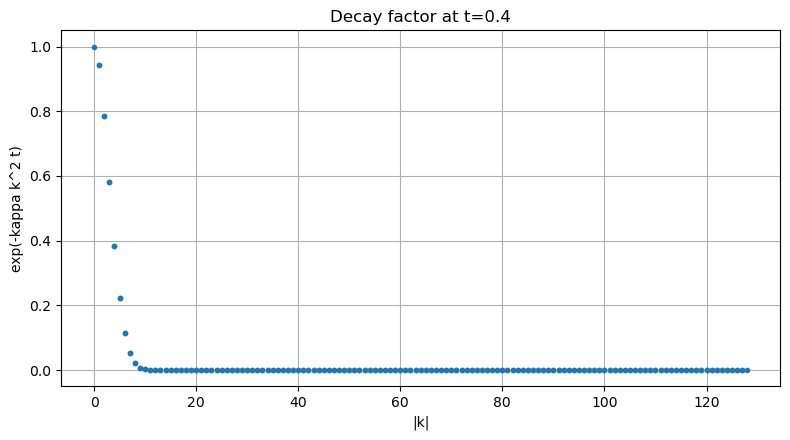

In [10]:
t = 0.4
decay = np.exp(-kappa * (k**2) * t)

plt.figure(figsize=(8, 4.5))
plt.plot(np.abs(k)[order], decay[order], 'o', markersize=3)
plt.title(f'Decay factor at t={t}')
plt.xlabel('|k|')
plt.ylabel('exp(-kappa k^2 t)')
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 10 — Make a time sequence

This gives a sequence of solutions showing the smoothing process over time.


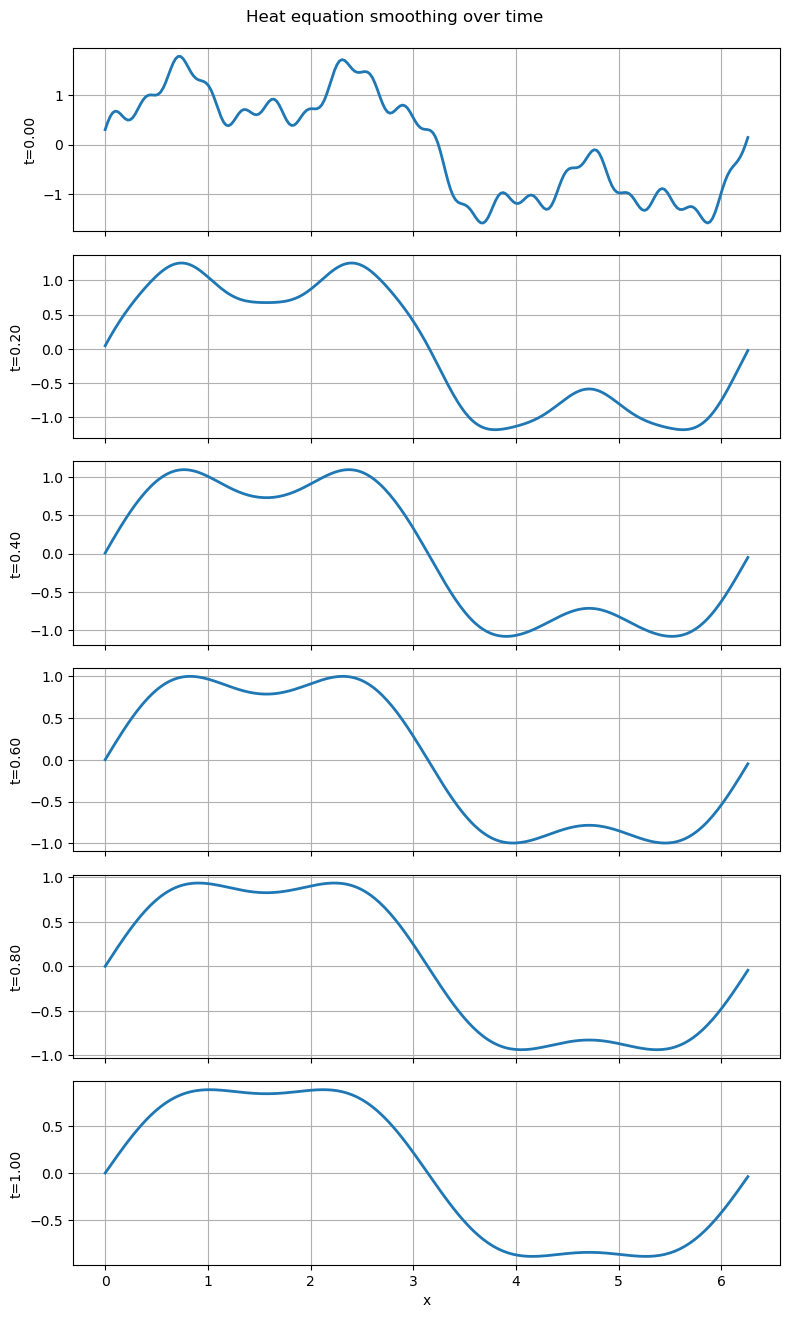

In [11]:
time_grid = np.linspace(0.0, 1.0, 6)

fig, axes = plt.subplots(len(time_grid), 1, figsize=(8, 2.2 * len(time_grid)), sharex=True)

for ax, t in zip(axes, time_grid):
    ut = heat_solution_fft(u0, k, kappa, t)
    ax.plot(x, ut, linewidth=2)
    ax.set_ylabel(f't={t:.2f}')
    ax.grid(True)

axes[-1].set_xlabel('x')
fig.suptitle('Heat equation smoothing over time', y=0.995)
plt.tight_layout()
plt.show()


## Step 11 — Single-mode check

If the initial condition is one Fourier mode,

$$u(x,0)=\sin(mx),$$

then the exact solution is

$$u(x,t)=e^{-\kappa m^2 t}\sin(mx).$$

This gives a clean correctness check.


RMS error for single-mode test: 2.327220258701576e-16


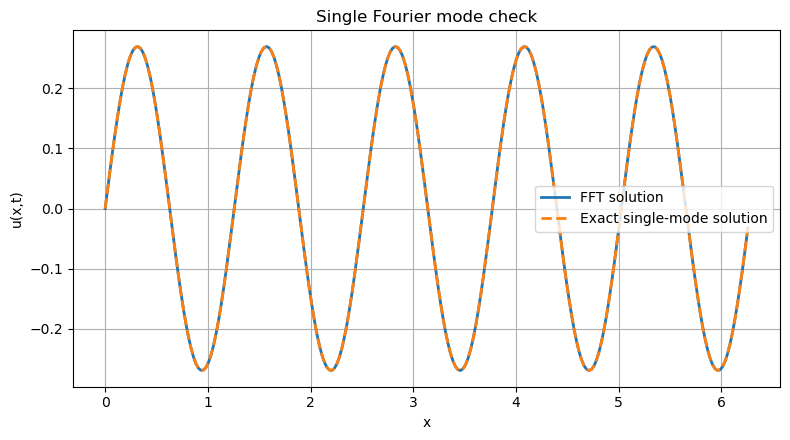

In [12]:
m = 5
u_single = np.sin(m * x)
t = 0.35

u_fft = heat_solution_fft(u_single, k, kappa, t)
u_exact = np.exp(-kappa * m**2 * t) * np.sin(m * x)

err = np.linalg.norm(u_fft - u_exact) / np.sqrt(n)
print('RMS error for single-mode test:', err)

plt.figure(figsize=(8, 4.5))
plt.plot(x, u_fft, label='FFT solution', linewidth=2)
plt.plot(x, u_exact, '--', label='Exact single-mode solution', linewidth=2)
plt.title('Single Fourier mode check')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Final summary

This notebook solved the periodic heat equation by moving to Fourier space.

The key ideas were:

- represent the solution in a Fourier basis
- use the fact that $u_{xx}$ becomes multiplication by $-k^2$
- evolve each Fourier mode exactly
- use the FFT and inverse FFT to move between physical space and Fourier space efficiently

So instead of solving one big coupled PDE directly, we solved many small scalar ODEs in the right basis.

## Suggested extensions

- try a 2D heat equation version
- compare against a finite-difference time-stepping method
- experiment with smoother or rougher initial conditions
- study how changing `kappa` affects decay speed
- test what happens if the initial condition has mostly high frequencies
